# A-RoF transmission

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent)

sys.path.append(project_path)

In [2]:
import pickle 
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, finddelay, decimate, upsample, clockSamplingInterp
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W

#from dpd.utils                import power_amplifier, calcACLR
from dpd.plots                import calc_per_carrier

from dpd.channel_models import RoF_channel
from dpd.utils import calcACLR

In [3]:
font = {'size':16}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - OFDM signal generation

In [4]:
# Parâmetros de modulação
modOrder  = 64                 # Modulation order
constType = 'qam'             # Constellation format
Rb = 5e9                     # Bitrate

# OFDM parameters
paramOFDM = parameters()
paramOFDM.G   = 32              
paramOFDM.SpS = 16

paramOFDM.Nfft = 2**10
paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)
paramOFDM.pilotCarriers = np.linspace(0, paramOFDM.Nfft - 1, 32, dtype = np.int64)

Nz = len(paramOFDM.nullCarriers)
Np = len(paramOFDM.pilotCarriers)
Ni = paramOFDM.Nfft - Nz - Np
numOFDMframes = 100

In [5]:
# Bits generation
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

# Symbols modulation
symbTx = modulateGray(bits, modOrder, constType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [6]:
# OFDM signal generation
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

Rs = Rb / ( Ni / (paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder))
Fs = Rs * paramOFDM.SpS

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = paramOFDM.SpS * paramOFDM.G * (1/Fs)
t_symb = paramOFDM.SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [7]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Sampling rate', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Symbol rate', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Bit rate', 'Rb', f'{Rb*1e-9:.2f} GHz'],
         ['Ordem da constelação', 'M', f'{modOrder}'],
         ['Nfft', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Cyclic prefix length', 'G', f'{paramOFDM.G}'],
         ['Number of information subcarriers', 'Ni', f'{Ni}'],
         ['Number of pilot subcarriers', 'Np', f'{Np}'],
         ['Number of null subcarriers', 'Nz', f'{Nz}'],
         ['Subcarriers spacing', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-3:.2f} kHz'],
         ['OFDM symbol period', 'T_symb', f'{1e6*t_symb:.2f} us'],
         ['Cyclic prefix duration', 'T_CP', f'{1e6*t_CP:.2f} us'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═══════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                          │ Parâmetro   │ Valor            │
╞═══════════════════════════════════╪═════════════╪══════════════════╡
│ Sampling rate                     │ Fs          │ 14.21 Gsamples/s │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Symbol rate                       │ Rs          │ 0.89 Gsymb/s     │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Bit rate                          │ Rb          │ 5.00 GHz         │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação              │ M           │ 64               │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Nfft                              │ Nfft        │ 1024             │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Cyclic prefix length              │ G           │ 32               │
├─────

### 2 - A-RoF channel

In [8]:
# MZM parameters
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi*0.5
paramMZM.P_laser = 0
paramMZM.Pin_MZM = 17

# RF parameters
paramRF = parameters()
paramRF.fc_e = 3.55e9
paramRF.bw = Rs
paramRF.Fs = Fs

# Optical fiber parameters
paramFiber = parameters()
paramFiber.L = 20
paramFiber.alpha = 0.2
paramFiber.D = 16
paramFiber.Fc = 193.1e12
paramFiber.Fs = Fs

# Photodiode parameters
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

# PA parameters
paramPA = parameters()
paramPA.model_name = "modified_rapp"
paramPA.g = 16
paramPA.x_sat = 1.9
paramPA.sigma_p = 1.1
paramPA.alpha = -345
paramPA.beta = 0.17
paramPA.q = 4

In [9]:
paramRoF = parameters()
paramRoF.paramMZM = paramMZM
paramRoF.paramRF = paramRF
paramRoF.paramFiber = paramFiber
paramRoF.paramPD = paramPD
paramRoF.paramPA = paramPA

sigRx_PA = RoF_channel(sigTx, paramRoF, filter_numtaps = 4096)

In [10]:
hlp = firwin(4096, Rs/1.75, fs = Fs)

sigRx = firFilter(hlp, sigRx_PA)
delay = finddelay(sigRx, sigTx)

sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

In [11]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = paramOFDM.SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx, paramDec).ravel()
symbRx = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.01449 
SNR = 19.181 dB
EVM = 10.008 %


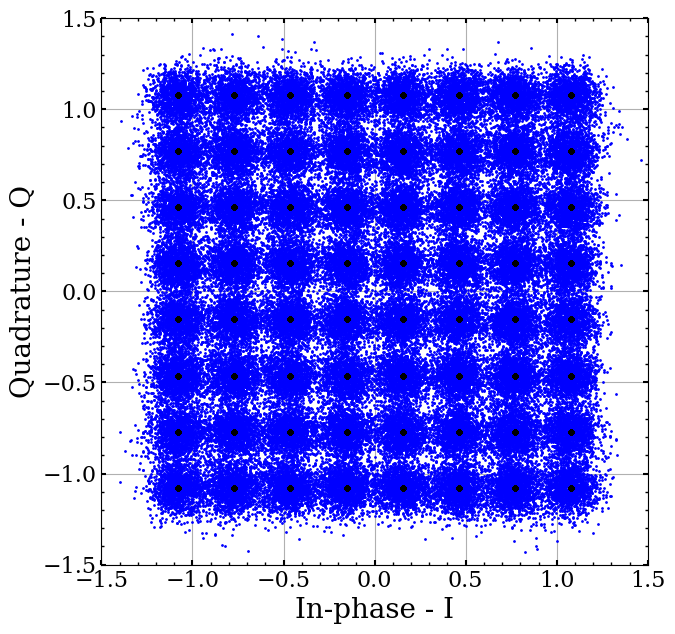

In [12]:
discard = 500
index = np.arange(discard, symbTx.size - discard)
BER, SER, SNR = fastBERcalc(symbRx[index], symbTx[index], modOrder, constType)

EVM = np.sqrt(calcEVM(symbRx, modOrder, constType))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB\nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx.real, symbRx.imag, "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
plt.grid()

plt.tight_layout()
#plt.savefig("constelacao_noDPD.png")

SigTx - ACLR = -31.304 dB
SigRx PA w/o DPD - ACLR = -24.961 dB


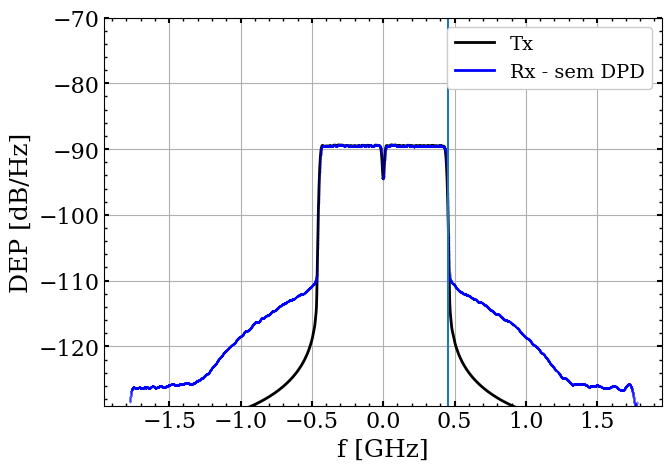

In [13]:
freq, P_sigTx    = welch(pnorm(sigTx)[0::paramOFDM.SpS//4], fs = 4*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA = welch(pnorm(sigRx_PA)[0::paramOFDM.SpS//4], fs = 4*Rs, nfft = 16*1024, return_onesided = False)

print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, Rs/2, 10e6):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, Rs/2, 10e6):.3f} dB")

fig, axs = plt.subplots(1, 1, figsize = (7, 5))

axs.plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA), "o", lw = 2, color = "b", ms = 0.1)

# Trick to improve legends
axs.plot(1, 1, lw = 2, color = "b", label = "Rx - sem DPD")

#axs.set_xlim(-0.2, 0.2)
axs.set_ylim(-129, -70)

axs.set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs.set_xlabel("f [GHz]", fontsize = 18)
axs.legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

axs.axvline( (0.5*Rs + 10e6) /1e9)

plt.tight_layout()
#plt.savefig("sig_freq_mpDPD.pdf")

In [25]:
# Save params
np.savetxt(file_path + r"\transmittedSignal\symbTx.txt", symbTx, fmt = '%f')
np.savetxt(file_path + r"\transmittedSignal\symbRx.txt", symbRx, fmt = '%f')
np.savetxt(file_path + r"\transmittedSignal\sigTx.txt", sigTx, fmt = '%f')
np.savetxt(file_path + r"\transmittedSignal\sigRx_PA.txt", sigRx_PA, fmt = '%f')

paramOFDM.numOFDMframes = numOFDMframes
paramOFDM.modOrder = modOrder
paramOFDM.modType = modType
paramOFDM.Rs = Rs
paramOFDM.Fs = Fs
paramOFDM.gain_pre_MZM_PA = (gain_pre_MZM, gain_pre_PA)

with open(file_path + r'\transmittedSignal\paramOFDM.pkl', 'wb') as f:
    pickle.dump(paramOFDM, f)
    f.close()

with open(file_path + r'\transmittedSignal\paramMZM.pkl', 'wb') as f:
    pickle.dump(paramMZM, f)
    f.close()

with open(file_path + r'\transmittedSignal\paramChannel.pkl', 'wb') as f:
    pickle.dump(paramChannel, f)
    f.close()

with open(file_path + r'\transmittedSignal\paramRF.pkl', 'wb') as f:
    pickle.dump(paramRF, f)
    f.close()

with open(file_path + r'\transmittedSignal\paramPD.pkl', 'wb') as f:
    pickle.dump(paramPD, f)
    f.close()

In [26]:
with open('saved_dictionary.pkl', 'wb') as f:
    pickle.dump(paramOFDM, f)
    f.close()
    
with open('saved_dictionary.pkl', 'rb') as inp:
    company1 = pickle.load(inp)
    f.close()